In [70]:
!pip install imblearn

In [71]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

# Load the dataset and take top 5 rows

In [72]:
kdd_cup99_dataset = pd.read_csv("kddcup99_csv.csv")
print(kdd_cup99_dataset.head())

   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2                     1.0                     0.0   
3           

# Check if the dataset has null or empty rows and check description

In [73]:

print(kdd_cup99_dataset.isnull().sum())
print(kdd_cup99_dataset.describe())

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
lnum_compromised               0
lroot_shell                    0
lsu_attempted                  0
lnum_root                      0
lnum_file_creations            0
lnum_shells                    0
lnum_access_files              0
lnum_outbound_cmds             0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

# Check all the columns in dataset

In [74]:
print(kdd_cup99_dataset.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'lnum_compromised', 'lroot_shell',
       'lsu_attempted', 'lnum_root', 'lnum_file_creations', 'lnum_shells',
       'lnum_access_files', 'lnum_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label'],
      dtype='object')


# Check the shape and details of the dataset for training

In [75]:
print(kdd_cup99_dataset.shape)
print(kdd_cup99_dataset.info())

(494020, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  object 
 2   service                      494020 non-null  object 
 3   flag                         494020 non-null  object 
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  lnum_compromised             494020 non-null 

# Plotting the histogram in dataset with all features

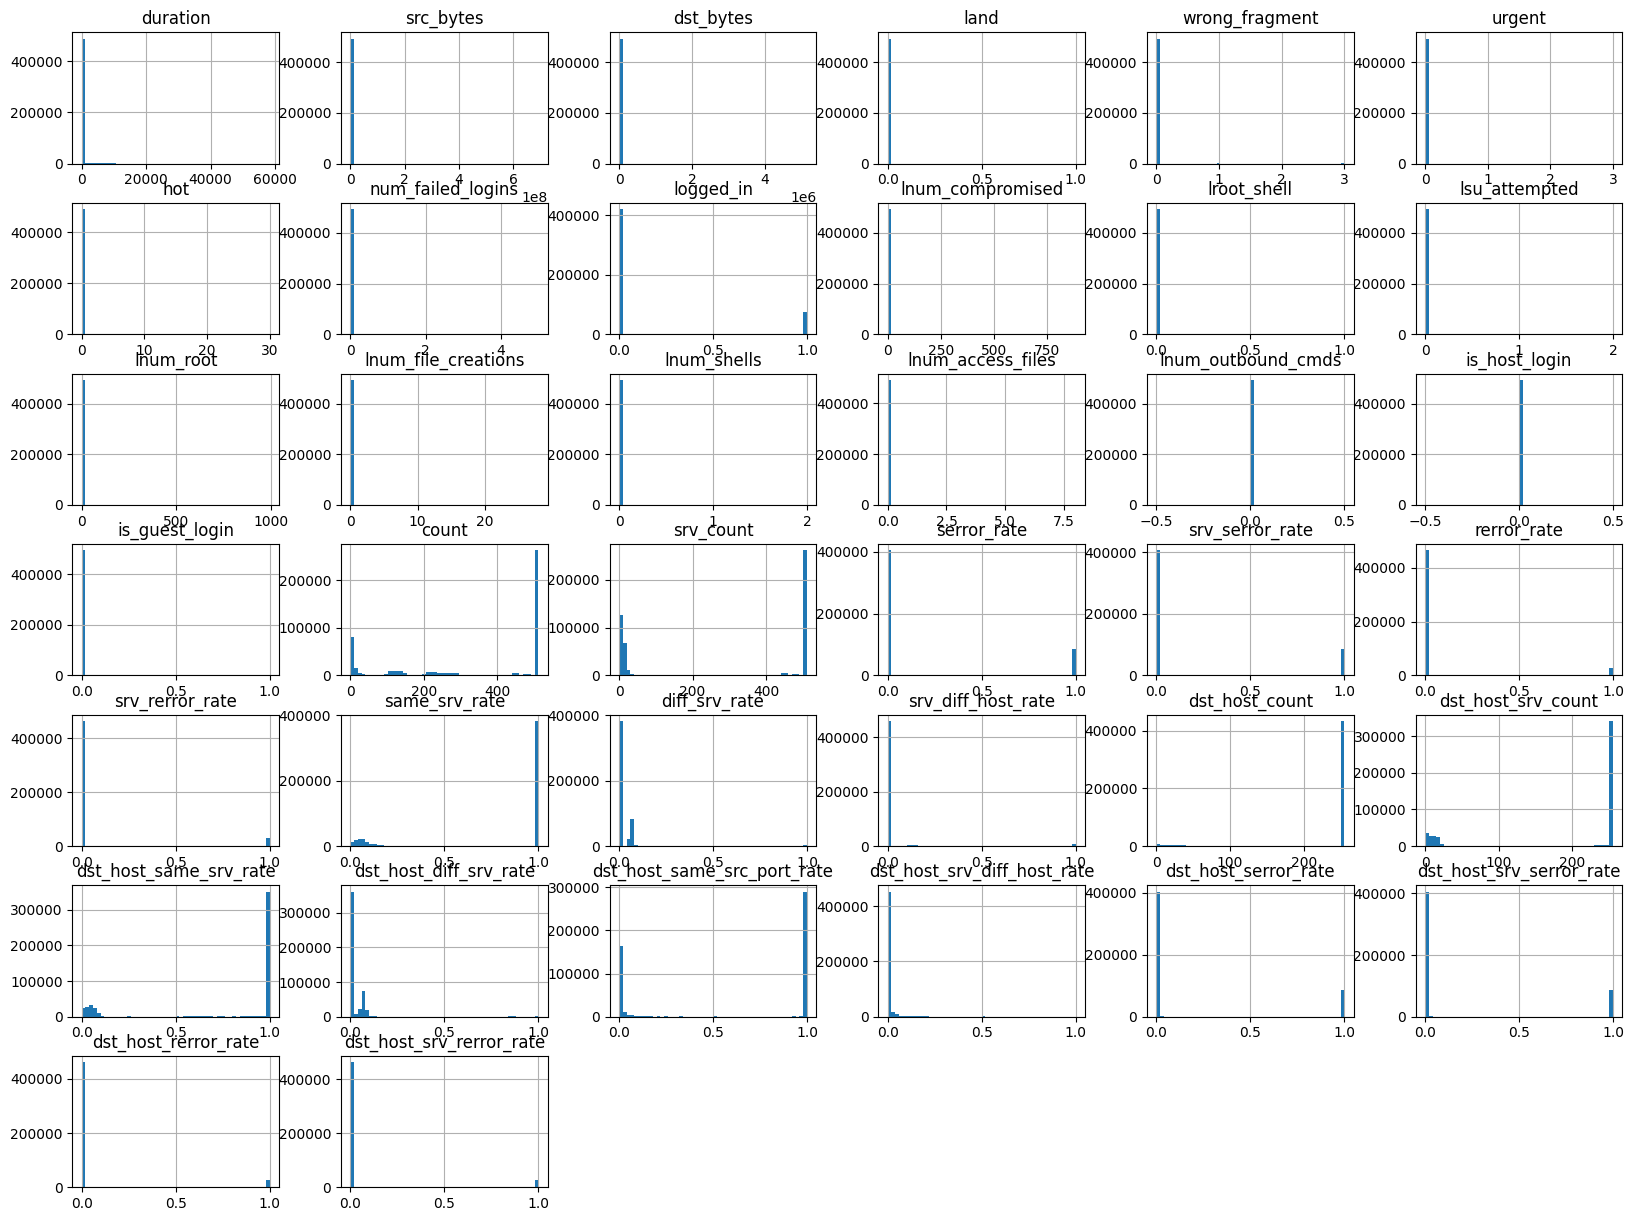

In [76]:
kdd_cup99_dataset.hist(bins=50, figsize=(20,15))
plt.show()

# Plotting features flag ,service , label and prototype and label

['flag', 'service', 'label', 'protocol_type']
Feature vise graphical representation


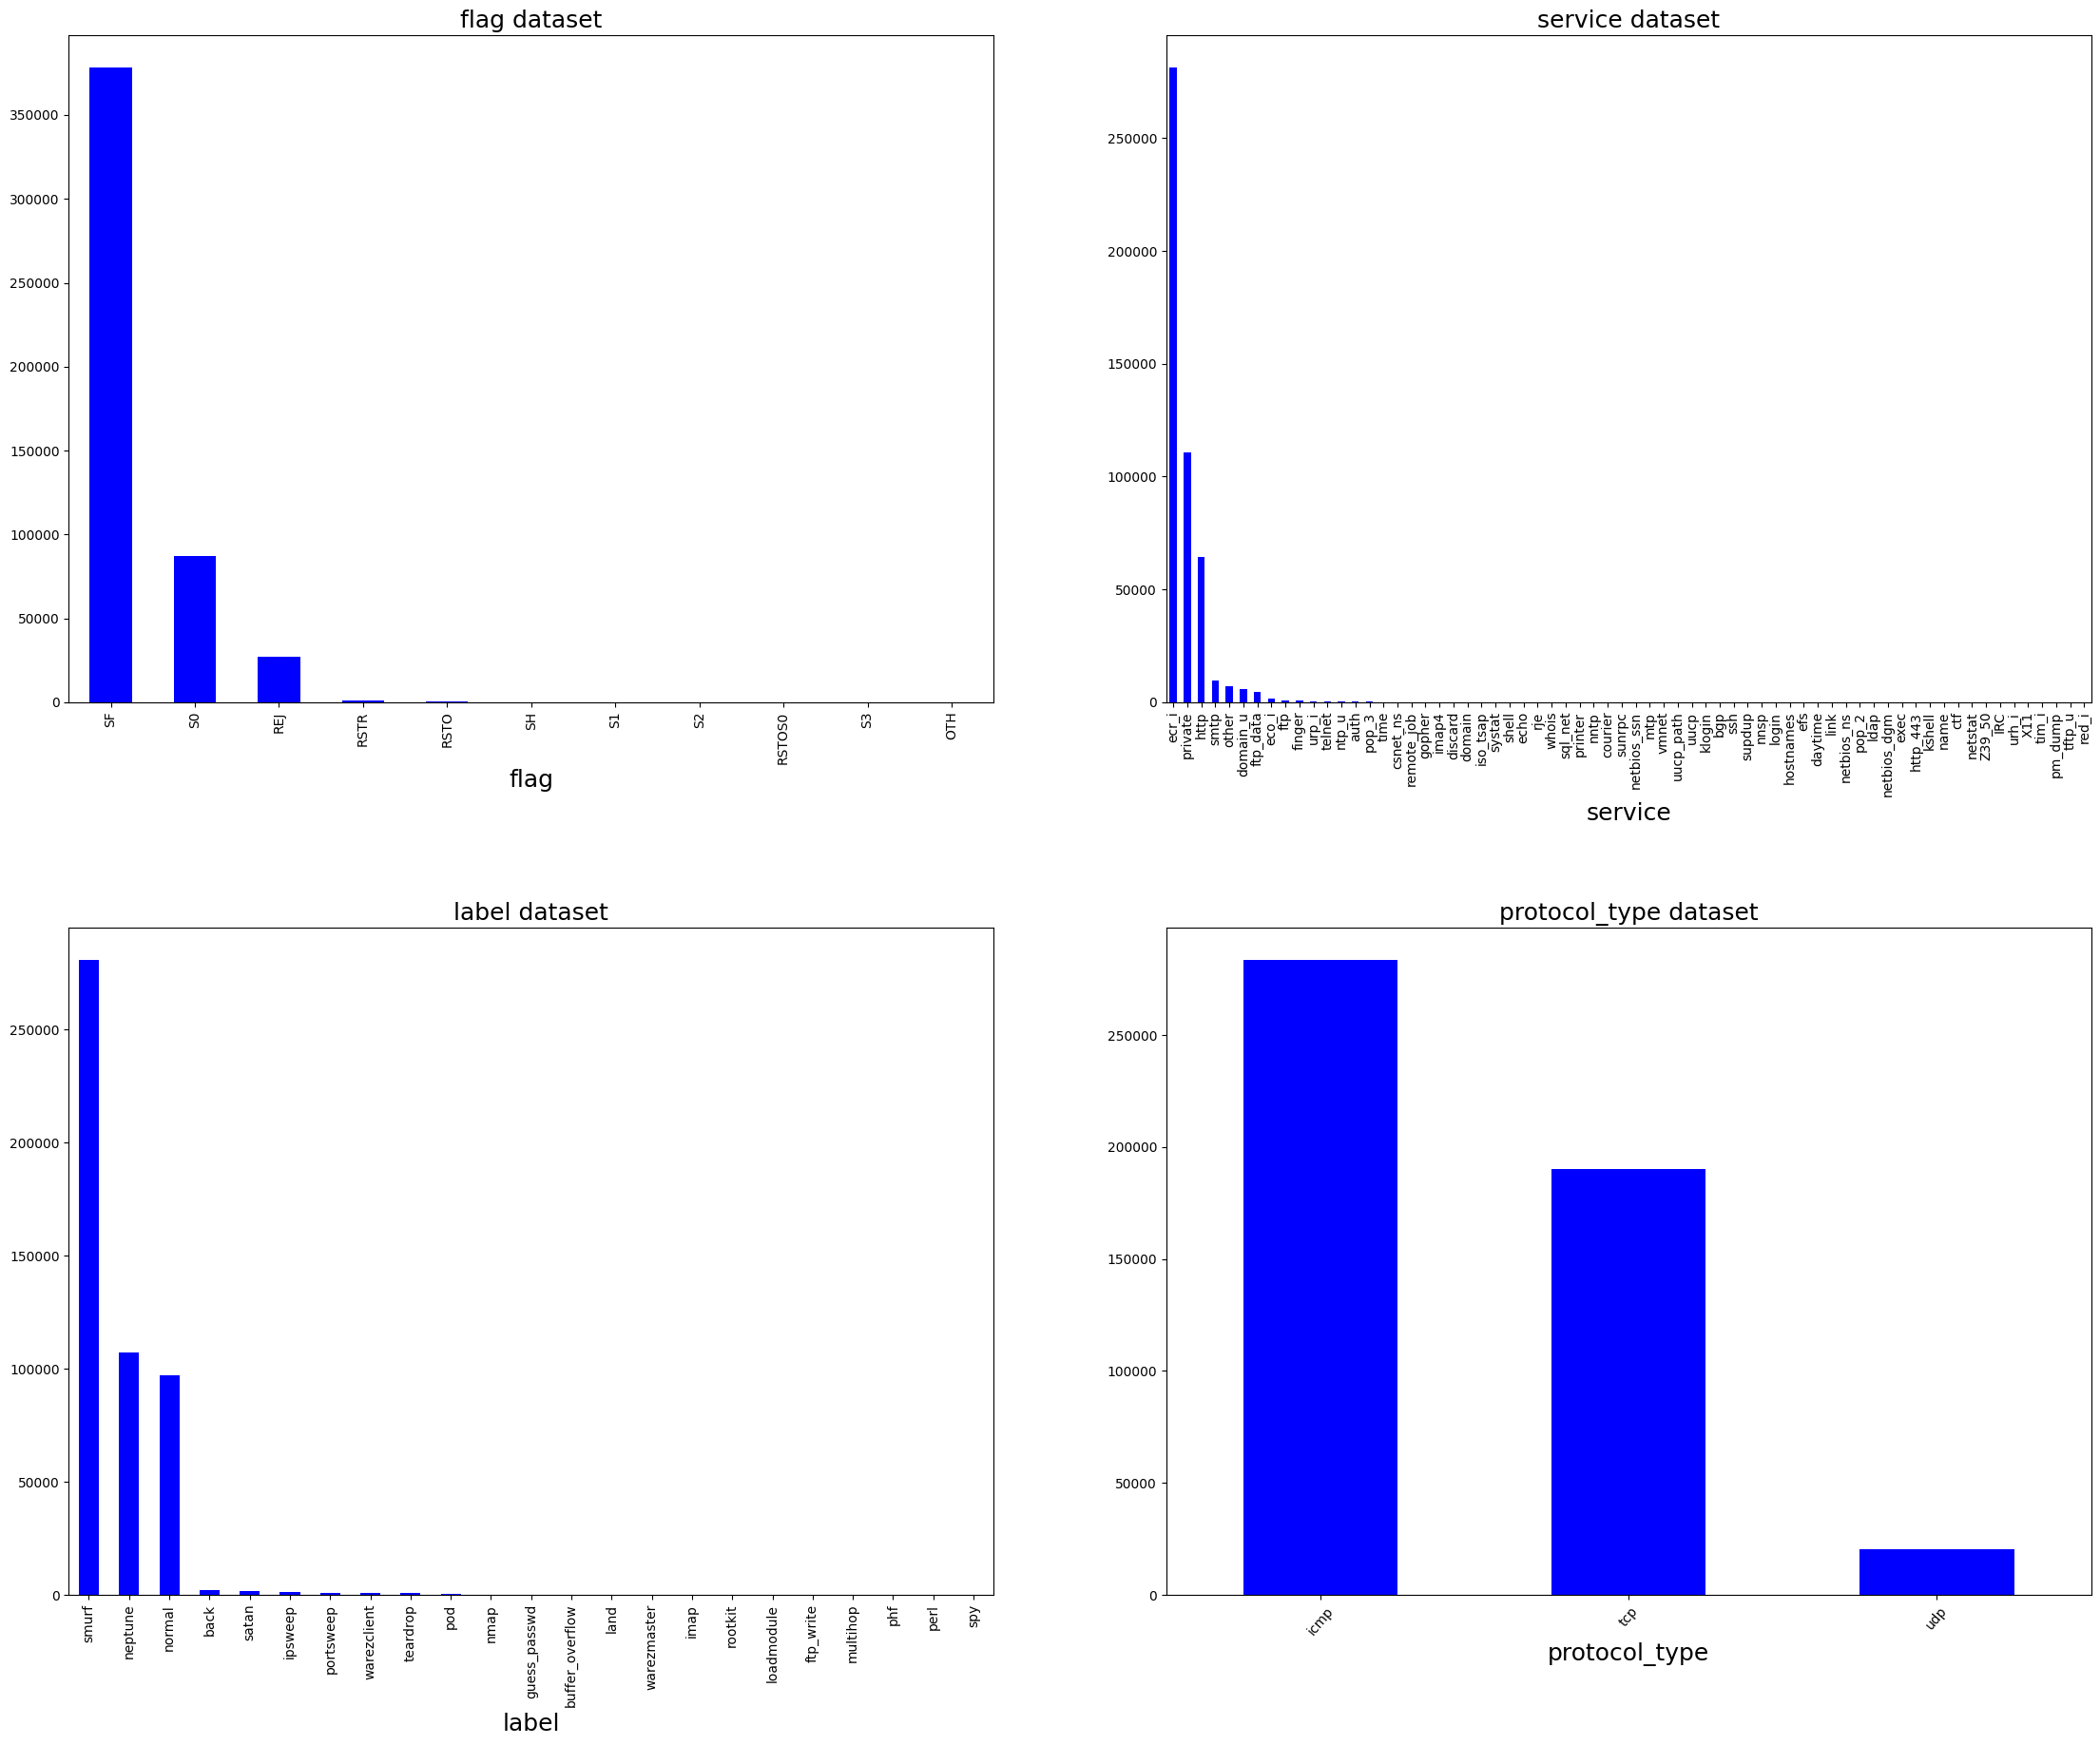

In [77]:
features = [kdd_cup99_dataset.columns[3],kdd_cup99_dataset.columns[2],kdd_cup99_dataset.columns[41],kdd_cup99_dataset.columns[1]]
print(features)

def plot_dist(col, ax):
    kdd_cup99_dataset[col].value_counts().plot(kind='bar', facecolor='b', ax=ax)
    ax.set_xlabel('{}'.format(col), fontsize=18)
    ax.set_title('{} dataset'.format(col), fontsize= 18)
    plt.xticks(rotation=50)
    return ax

f, ax = plt.subplots(2,2, figsize = (22,20))
f.tight_layout(h_pad=15, w_pad=10, rect=[0, 0.08, 1, 0.93])

k = 0
for i in range(2):
    for j in range(2):
        plot_dist(features[k], ax[i][j])
        k += 1

        
print('Feature vise graphical representation')
plt.show()

# Plotting frequency of labels present in dataset

In [78]:
def plot_labels_dataset():
    print(kdd_cup99_dataset['label'].value_counts())
    (kdd_cup99_dataset.drop_duplicates(inplace=True))
    #print(kdd_cup99_dataset)
    plt.figure(figsize=(12, 6))
    kdd_cup99_dataset['label'].value_counts().plot(kind='bar', color='yellow', edgecolor='black')
    plt.title('Labels in KDD Cup 1999 Dataset')
    plt.xlabel('Label')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

label
smurf              280790
neptune            107201
normal              97277
back                 2203
satan                1589
ipsweep              1247
portsweep            1040
warezclient          1020
teardrop              979
pod                   264
nmap                  231
guess_passwd           53
buffer_overflow        30
land                   21
warezmaster            20
imap                   12
rootkit                10
loadmodule              9
ftp_write               8
multihop                7
phf                     4
perl                    3
spy                     2
Name: count, dtype: int64


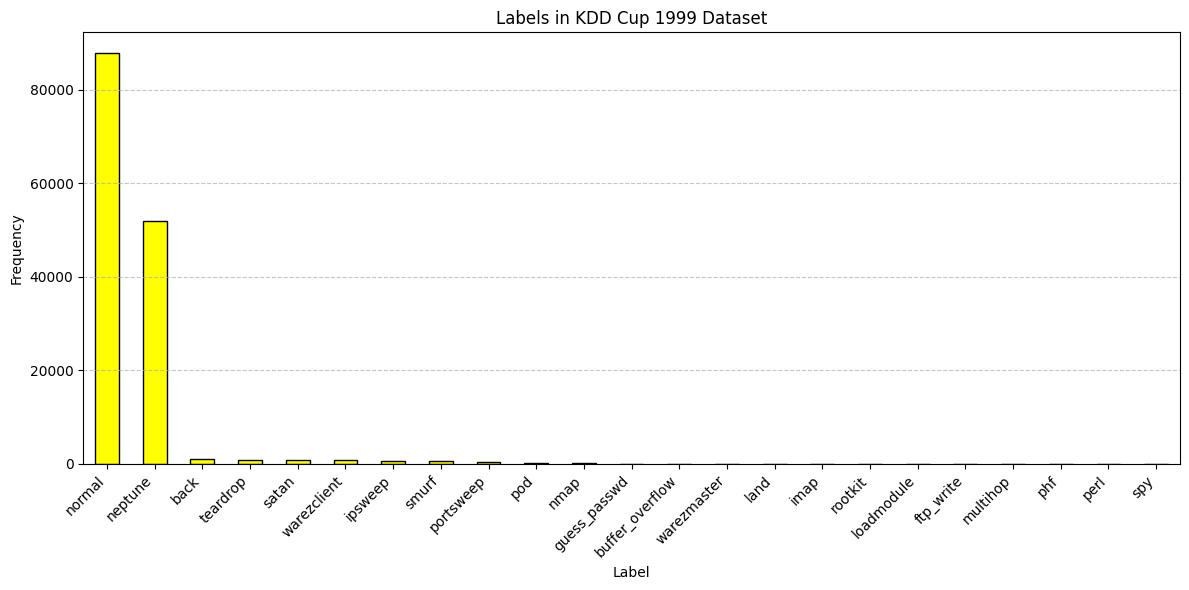

In [79]:
plot_labels_dataset()

# Analyzing the shape and of features X and target Y before training the model

In [80]:
def analyze_dataset():
    X = kdd_cup99_dataset.drop('label', axis=1)
    y = kdd_cup99_dataset['label']

    print("Shape of the dataset:")
    print(f"X: {X.shape}")
    print(f"y: {y.shape}")

    print("\nUnique values in the 'label' column:")
    print(y.value_counts())

    print("\nSample of the first few rows:")
    print(kdd_cup99_dataset.head())

analyze_dataset()

Shape of the dataset:
X: (145585, 41)
y: (145585,)

Unique values in the 'label' column:
label
normal             87831
neptune            51820
back                 968
teardrop             918
satan                906
warezclient          893
ipsweep              651
smurf                641
portsweep            416
pod                  206
nmap                 158
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  19
imap                  12
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Sample of the first few rows:
   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337   

In [81]:
def Train_Test_LogisticRegression():
    X = kdd_cup99_dataset.drop('label', axis=1)
    y = kdd_cup99_dataset['label']
    
    y_binary = np.where((y == 'ipsweep') | (y== 'nmap') | (y=='portsweep') | (y == 'satan'), 1, -1)

    print('Original target distribution', pd.Series(y_binary).value_counts(normalize=True))

    encoder = OneHotEncoder(sparse_output=False)
    X_encoded = encoder.fit_transform(X.select_dtypes(include=['object']))
    
    X_non_categorical = X.select_dtypes(exclude=['object']).values
    X_final = pd.concat([pd.DataFrame(X_non_categorical), pd.DataFrame(X_encoded)], axis=1)    
    
    X_train, X_test, y_train, y_test = train_test_split(X_final, y_binary, test_size=0.2, random_state=42)
    
    undersampler = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

    print('Resampled target distribution',pd.Series(y_train_resampled).value_counts(normalize=True))
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=100)
    model.fit(X_train_scaled, y_train_resampled)
    
    train_accuracy = model.score(X_train_scaled, y_train_resampled)
    test_accuracy = model.score(X_test_scaled, y_test)
    
    print(f"Training Accuracy for logistic model: {train_accuracy:.4f}")
    print(f"Testing Accuracy for logistic model: {test_accuracy:.4f}")
    print(f"Number of iterations for logistic model: {model.n_iter_}")
    
    y_pred = model.predict(X_test_scaled)

   
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:",cm)



    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    return model,X_final.columns,y_train_resampled,X_train_scaled,y_test,X_test_scaled,X.columns

In [82]:
Train_Test_LogisticRegression()

Original target distribution -1    0.985363
 1    0.014637
Name: proportion, dtype: float64
Resampled target distribution -1    0.5
 1    0.5
Name: proportion, dtype: float64
Training Accuracy for logistic model: 0.9846
Testing Accuracy for logistic model: 0.9846
Number of iterations for logistic model: [43]
Confusion Matrix: [[28237   441]
 [    7   432]]
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.98      0.99     28678
           1       0.49      0.98      0.66       439

    accuracy                           0.98     29117
   macro avg       0.75      0.98      0.83     29117
weighted avg       0.99      0.98      0.99     29117



(LogisticRegression(),
 Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
        ...
        70, 71, 72, 73, 74, 75, 76, 77, 78, 79],
       dtype='int64', length=118),
 array([-1, -1, -1, ...,  1,  1,  1]),
 array([[-0.14038204, -0.01732055, -0.09839286, ...,  0.        ,
          0.99704927, -0.08627103],
        [-0.14065323, -0.01738986,  1.05755103, ...,  0.        ,
          0.99704927, -0.08627103],
        [-0.14065323, -0.01737845,  0.22381472, ...,  0.        ,
          0.99704927, -0.08627103],
        ...,
        [-0.14065323, -0.01740571, -0.14178434, ...,  0.        ,
          0.99704927, -0.08627103],
        [-0.14038204, -0.01740588, -0.13765182, ...,  0.        ,
          0.99704927, -0.08627103],
        [-0.14065323, -0.01740571, -0.14178434, ...,  0.        ,
          0.99704927, -0.08627103]]),
 array([-1,  1, -1, ..., -1, -1, -1]),
 array([[-0.14065323, -0.01737668,  0.90593913, ...,  0.        ,
          0.99704927, -0.08627103],
        [-0.14065323, -0.0

After checking the statistics and the accuracy reports 
The Logistic regression model is showing brilliant performance with very high accuracy on both the training and testing sets having 98% and more.
The training accuracy as shown above is 98.46% which is same as the testing accuracy of the logistic model. Thus it is suggesting that the model is not overfitting a lot.
Based on number of iterations computed ,the logistic model converges quickly in about 43 iterations effectively optimized.
The logistic model performs really well on the majority class which is -1 , having almost perfect precision (1.00), high recall (0.98), and a high F1-score (0.99) as shown above in the classification report. 
For the minority class which is 1, the model has very good recall 0.98 but lower precision 0.49, resulting in a resulting in a moderate F1-score which is 0.66. Inspite of having extreme original imbalance as seen above,the model performs well on both classes after resampling the data well.

The high recall for the minority class being 0.98 is good indicating that the model doesnt really miss the positive cases.
The LR model has a very high number of false positives  which is around 441 shown above as compared to true positives which is 432 shown above for the minority class, which explains the lower precision for this class.

The model quickly identifies the majority class which is -1 with correct metric.
For the minority class which is 1, the logistic regression model is rarely missing true positives (high recall) but has a high tendency to overpredict which indicates lower precision.
The resampling strategy was effective in improving the model's performance on the minority class, especially in terms of recall but at the cost of precision.
Therefore the logistic regression model performs really well overall, with only minor signs of overfitting. It converges quickly and handles the balanced and imbalanced classes effectively.
The logistic regression model has a very quick convergence and high performance indicating that it's good for this dataset.
Thus based on the trade-off shown above between precision and recall for the minority class.
Hence the logistic regression model indicates having good performance,with the original extreme class imbalance, and demonstrating good generalization to the test dataset. Although, having low precision for the minority class indicates that the model may be overpredicting this class,due to the resampling strategy.



# Finding most important features based on higher weight values

In [83]:
def important_features_weight():
    model,X_final,y_train_resampled,X_train_scaled,y_test,X_test_scaled,X_cols = Train_Test_LogisticRegression()
    features = X_cols
    weights = abs(model.coef_[0])
    
    min_length = min(len(features), len(weights))
    features = features[:min_length]
    weights = weights[:min_length]
    
    df_weight = pd.DataFrame({'Feature':X_cols, 'Weight': weights})
    weights_df_sorting = df_weight.sort_values(by='Weight', ascending=False)
    print(weights_df_sorting)
important_features_weight()

Original target distribution -1    0.985363
 1    0.014637
Name: proportion, dtype: float64
Resampled target distribution -1    0.5
 1    0.5
Name: proportion, dtype: float64
Training Accuracy for logistic model: 0.9846
Testing Accuracy for logistic model: 0.9846
Number of iterations for logistic model: [43]
Confusion Matrix: [[28237   441]
 [    7   432]]
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.98      0.99     28678
           1       0.49      0.98      0.66       439

    accuracy                           0.98     29117
   macro avg       0.75      0.98      0.83     29117
weighted avg       0.99      0.98      0.99     29117

                        Feature    Weight
26                  rerror_rate  2.921476
19           lnum_outbound_cmds  1.725437
32           dst_host_srv_count  1.630994
33       dst_host_same_srv_rate  1.627114
8                        urgent  1.279597
34       dst_host_diff_srv_rate  1.2322

Original target distribution -1    0.985363
 1    0.014637
Name: proportion, dtype: float64
Resampled target distribution -1    0.5
 1    0.5
Name: proportion, dtype: float64
Training Accuracy for logistic model: 0.9846
Testing Accuracy for logistic model: 0.9846
Number of iterations for logistic model: [43]
Confusion Matrix: [[28237   441]
 [    7   432]]
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.98      0.99     28678
           1       0.49      0.98      0.66       439

    accuracy                           0.98     29117
   macro avg       0.75      0.98      0.83     29117
weighted avg       0.99      0.98      0.99     29117



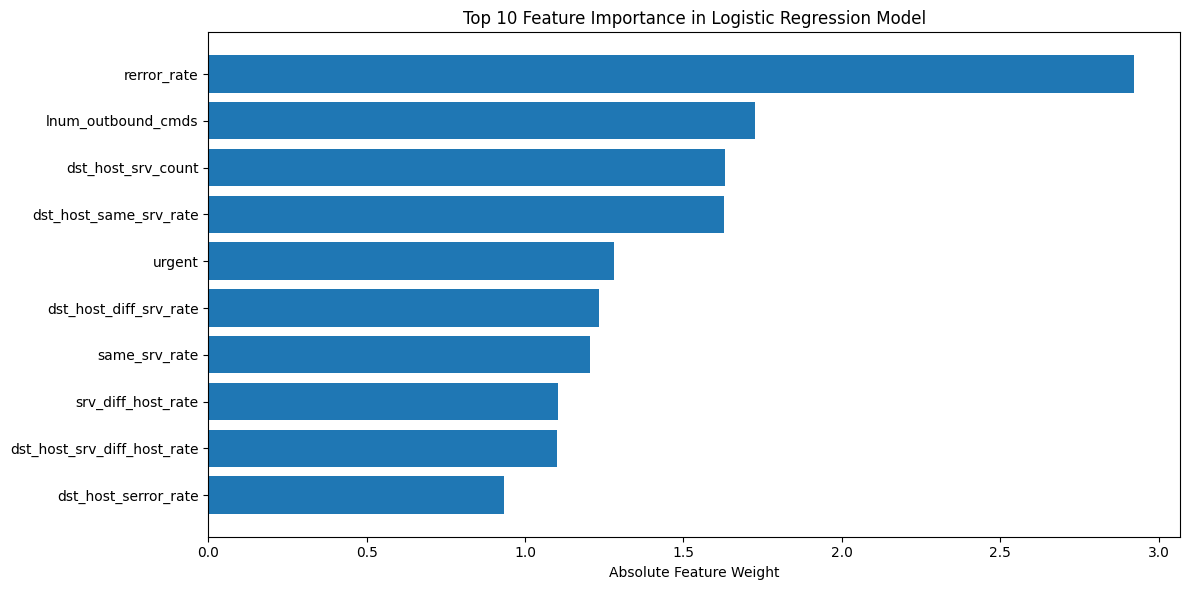

In [84]:
def Feature_imp_trained_weights():
    model, features, y_train_resampled, X_train_scaled, y_test, X_test_scaled, X_cols = Train_Test_LogisticRegression()
    
    feature_importance = abs(model.coef_[0])
    
    valid_indices = np.where(np.arange(len(feature_importance)) < len(X_cols))[0]
    feature_importance = feature_importance[valid_indices]
    
    n_top_features = min(10, len(feature_importance))
    sorted_idx = np.argsort(feature_importance)[-n_top_features:]
    
    pos = np.arange(len(sorted_idx)) + 0.5
    
    plt.figure(figsize=(12, 6))
    plt.barh(pos, feature_importance[sorted_idx], align='center')
    plt.yticks(pos, [X_cols[i] for i in sorted_idx])
    plt.xlabel('Absolute Feature Weight')
    plt.title(f'Top {n_top_features} Feature Importance in Logistic Regression Model')
    plt.tight_layout()
    plt.show()

Feature_imp_trained_weights()

The trained model parameters for the logistic regression indicate that the above features having the largest weights in absolute value are more important and influential in predicting the outcome or target thus ,indicating a strong influence while making the prediction of the outcome. 
After plotting top 10 features and calculating the weights and features found that the features does make sense as they are capturing various aspect of the network traffic and their behaviour which are very commonly associated with network intrusion detection, like various connection patterns then the error rates and service usage. Network Anomalies in these calculated metrics are often prone to network signal potential threats or having like unusual network activity,which make adds value to a model that is focused on detecting network intrusions or anomalies in network traffic.

Original target distribution -1    0.985363
 1    0.014637
Name: proportion, dtype: float64
Resampled target distribution -1    0.5
 1    0.5
Name: proportion, dtype: float64
Training Accuracy for logistic model: 0.9846
Testing Accuracy for logistic model: 0.9846
Number of iterations for logistic model: [43]
Confusion Matrix: [[28237   441]
 [    7   432]]
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.98      0.99     28678
           1       0.49      0.98      0.66       439

    accuracy                           0.98     29117
   macro avg       0.75      0.98      0.83     29117
weighted avg       0.99      0.98      0.99     29117


L1 Regularization:
Training Accuracy: 0.9852
Testing Accuracy: 0.9848

L2 Regularization:
Training Accuracy: 0.9846
Testing Accuracy: 0.9846
     Feature  L1 weight  L2 weight
0          0  -0.916330  -0.830997
1          1   0.124183   0.172256
2          2   0.000000  -0.400524
3        

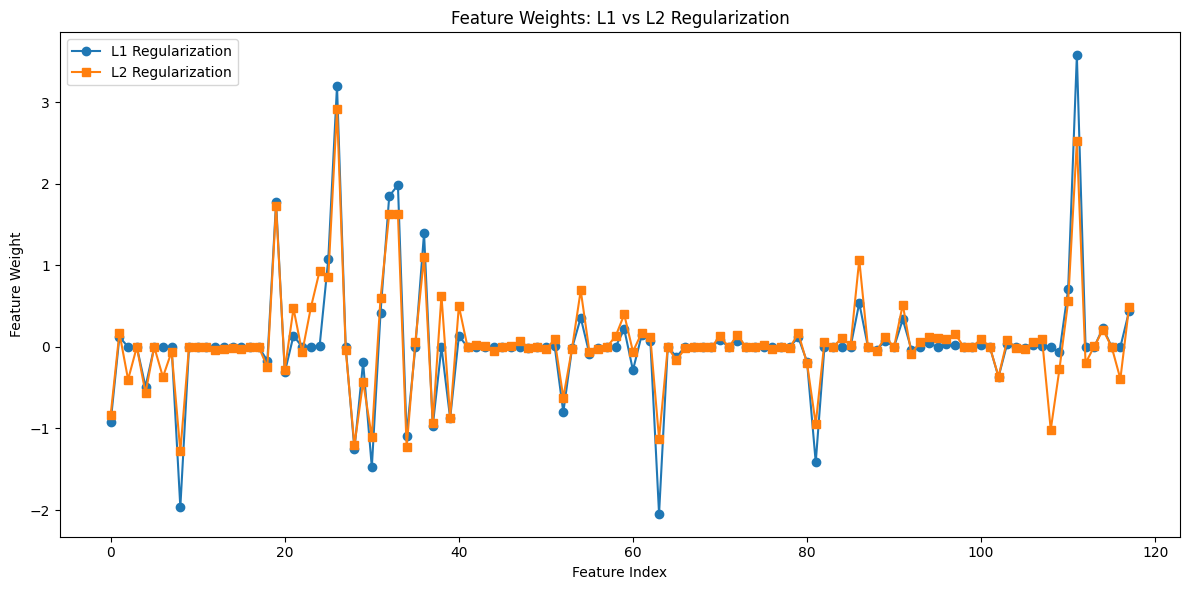

In [85]:
model,features,y_train_resampled,X_train_scaled,y_test,X_test_scaled,X_cols= Train_Test_LogisticRegression()


model_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)
model_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)

model_l1.fit(X_train_scaled, y_train_resampled)
model_l2.fit(X_train_scaled, y_train_resampled)

print("\nL1 Regularization:")
print(f"Training Accuracy: {model_l1.score(X_train_scaled, y_train_resampled):.4f}")
print(f"Testing Accuracy: {model_l1.score(X_test_scaled, y_test):.4f}")

print("\nL2 Regularization:")
print(f"Training Accuracy: {model_l2.score(X_train_scaled, y_train_resampled):.4f}")
print(f"Testing Accuracy: {model_l2.score(X_test_scaled, y_test):.4f}")

weights_l1 = model_l1.coef_[0]
weights_l2 = model_l2.coef_[0]
weights_df = pd.DataFrame({
    'Feature':features,
    'L1 weight':weights_l1,
    'L2 weight':weights_l2
})
print(weights_df)

# Plot feature weights comparison
plt.figure(figsize=(12, 6))
plt.plot(model_l1.coef_[0], label='L1 Regularization', marker='o')
plt.plot(model_l2.coef_[0], label='L2 Regularization', marker='s')
plt.xlabel('Feature Index')
plt.ylabel('Feature Weight')
plt.title('Feature Weights: L1 vs L2 Regularization')
plt.legend()
plt.tight_layout()
plt.show()

Original target distribution -1    0.985363
 1    0.014637
Name: proportion, dtype: float64
Resampled target distribution -1    0.5
 1    0.5
Name: proportion, dtype: float64
Training Accuracy for logistic model: 0.9846
Testing Accuracy for logistic model: 0.9846
Number of iterations for logistic model: [43]
Confusion Matrix: [[28237   441]
 [    7   432]]
Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.98      0.99     28678
           1       0.49      0.98      0.66       439

    accuracy                           0.98     29117
   macro avg       0.75      0.98      0.83     29117
weighted avg       0.99      0.98      0.99     29117



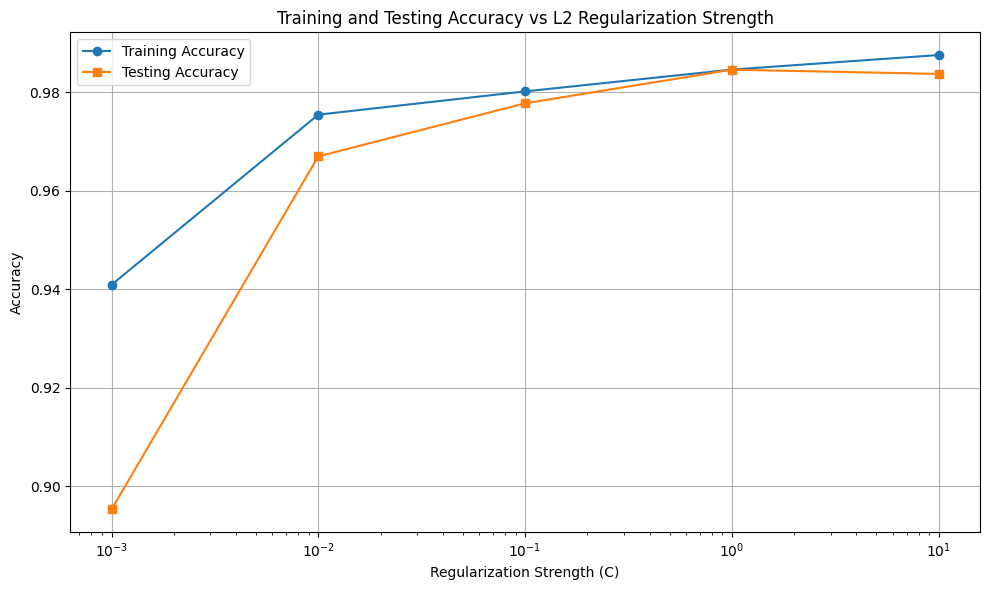

In [88]:
def L2regularization():
    train_accuracies = []
    test_accuracies = []
    model,features,y_train_resampled,X_train_scaled,y_test,X_test_scaled,X_cols = Train_Test_LogisticRegression()

    for C in [0.001, 0.01, 0.1, 1, 10]:
        model = LogisticRegression(penalty='l2', C=C, max_iter=1000)
        model.fit(X_train_scaled, y_train_resampled)
        train_accuracies.append(model.score(X_train_scaled, y_train_resampled))
        test_accuracies.append(model.score(X_test_scaled, y_test))
    
    plt.figure(figsize=(10, 6))
    plt.semilogx([0.001, 0.01, 0.1, 1, 10], train_accuracies, label='Training Accuracy', marker='o')
    plt.semilogx([0.001, 0.01, 0.1, 1, 10], test_accuracies, label='Testing Accuracy', marker='s')
    plt.xlabel('Regularization Strength (C)')
    plt.ylabel('Accuracy')
    plt.title('Training and Testing Accuracy vs L2 Regularization Strength')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
L2regularization()

After plotting and calculating the regularization with training and testing accuracy plotting them provides ideas into model performance whether it is good or bad and highlights the important features with changes in L2 regularization strengths
After checking the plots, As the L2 regularization strength mentioned in the question keeps on increasing, the training and the testing accuracy initially increases. Suggesting that a small amount of regularization helps prevent model overfitting by putting penalties on large values and coefficients leading to better generalization.

On Further, analyzing the graph, the accuracy is constant or there is no significant change i.e. comes to a plateau, which indicates that on further change in regularization values, the model performance is not changing. As the model is reaching and trying to maintain an optimal balance between the bias and variance.

when the regularization is very low i.e. 0.001, The logistic regression model might overfit the training data, which may lead to a very high training accuracy but potentially lower testing accuracy.

When the Regularization is mid or medium i.e. 0.1 to 1,  This range is often a good trade-off, thereby improving generalization by reducing overfitting.

Lastly, when the Regularization is high i.e. 10,  It leads to very high regularization that could lead to underfitting, wherein both the training and testing accuracy might decrease slightly.
Also, The features having the largest weights with absolute values are very highly informative and also useful for predicting the outcome of the model.

Thereby, We can conclude that the results make sense as the dataset provided is for network intrusion detection.
There has to be a balance between regularization strength and the model performance as it's very crucial for achieving higher accuracy without overfitting.

Also based on weights for the trained model parameters it highlights the important features that will help and is a crucial indicator for the network anomaly. Thereby supporting their importance in the model's prediction.
Overall, the above analysis shows the importance of tuning the parameters for regularization and knowing the feature importance to optimize logistic regression model performance effectively.